# Lecture 4 companion — From one neuron to a small MLP

**Run it:** upload this file to Google Colab, or use the short
[setup guide](../../week02/SETUP.md).

## Goal

Build the pieces in NumPy, trace one forward and backward pass, then use
scikit-learn to train complete models.

> inputs → weighted sum → activation → prediction → loss → gradients → update

## How to use this notebook

1. Predict the output or shape before running a cell.
2. Run the cell with **Shift + Enter**.
3. Explain what each intermediate value means.
4. Treat plotting helpers as provided tools; focus on the model code.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import make_moons
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=3, suppress=True)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.1.3
scikit-learn: 1.6.1


## 1. A curved classification problem

Each row has two features. The target is either class `0` or class `1`.
Sketch a boundary before running the plot.

In [2]:
X, y = make_moons(n_samples=180, noise=0.18, random_state=7)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("first three examples:\n", X[:3])
print("first three targets:", y[:3])

X shape: (180, 2)
y shape: (180,)
first three examples:
 [[ 0.849 -0.504]
 [ 0.513  1.443]
 [ 1.628  0.138]]
first three targets: [1 0 1]


In [3]:
# Visualization helper: you do not need to understand this plotting code yet.
BLUE = "#2563EB"
ORANGE = "#F97316"
INK = "#111827"

def plot_examples(features, targets, title):
    for class_value, color, marker in [(0, BLUE, "o"), (1, ORANGE, "^")]:
        selected = targets == class_value
        plt.scatter(features[selected, 0], features[selected, 1],
                    color=color, marker=marker, s=48, label=f"class {class_value}")
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_boundary(model, features, targets, title):
    x0, x1 = np.meshgrid(
        np.linspace(features[:, 0].min() - 0.4, features[:, 0].max() + 0.4, 220),
        np.linspace(features[:, 1].min() - 0.4, features[:, 1].max() + 0.4, 180),
    )
    grid = np.column_stack([x0.ravel(), x1.ravel()])
    probability = model.predict_proba(grid)[:, 1].reshape(x0.shape)
    plt.contourf(x0, x1, probability, levels=[0, 0.5, 1],
                 colors=["#DBEAFE", "#FFEDD5"], alpha=0.75)
    plt.contour(x0, x1, probability, levels=[0.5], colors=[INK], linewidths=2)
    plot_examples(features, targets, title)

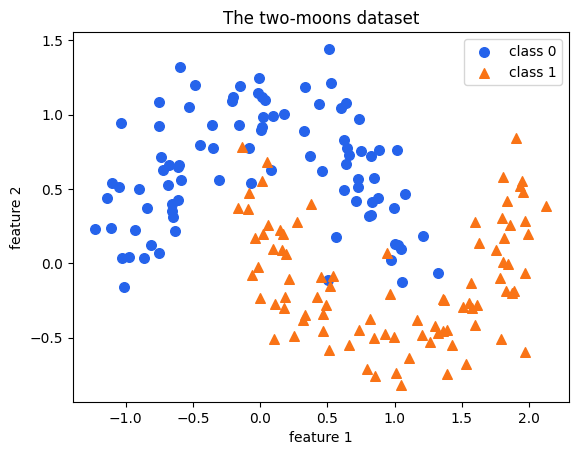

In [4]:
plot_examples(X, y, "The two-moons dataset")

### Check

- What does one row of `X` represent?
- Why might one straight line struggle with this pattern?

## 2. The linear model is one neuron

Lecture 3 used the same weighted sum:

```text
output = inputs @ weights + bias
```

For regression, this number can be the final prediction.

In [5]:
def linear_output(inputs, weights, bias):
    return inputs @ weights + bias

In [6]:
example = np.array([1.2, 0.5])
weights = np.array([0.8, -0.3])
bias = 0.4

output = linear_output(example, weights, bias)
print("weighted sum + bias:", output)

weighted sum + bias: 1.21


### Predict before running

Which part changes if we use the same neuron for binary classification:
the weighted sum, or what we do with its output?

## 3. Sigmoid turns a score into a probability

Sigmoid always returns a value between 0 and 1. A score of zero becomes
probability `0.5`.

In [7]:
def sigmoid(scores):
    return 1 / (1 + np.exp(-scores))

In [8]:
test_scores = np.array([-4.0, 0.0, 4.0])
test_probabilities = sigmoid(test_scores)

print("scores:       ", test_scores)
print("probabilities:", test_probabilities)
assert np.isclose(sigmoid(0), 0.5)

scores:        [-4.  0.  4.]
probabilities: [0.018 0.5   0.982]


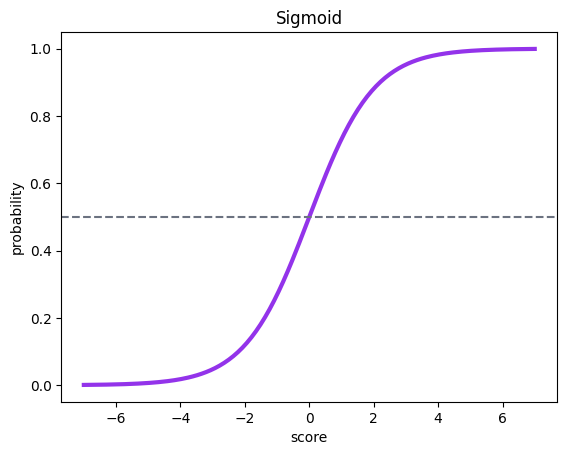

In [9]:
scores = np.linspace(-7, 7, 200)
plt.plot(scores, sigmoid(scores), color="#9333EA", linewidth=3)
plt.axhline(0.5, color="#6B7280", linestyle="--")
plt.xlabel("score")
plt.ylabel("probability")
plt.title("Sigmoid")
plt.show()

## 4. A complete classification neuron

The neuron first calculates a score, then applies an activation.

In [10]:
def neuron_forward(inputs, weights, bias, activation):
    scores = linear_output(inputs, weights, bias)
    outputs = activation(scores)
    return outputs

In [11]:
probability = neuron_forward(example, weights, bias, sigmoid)
predicted_class = int(probability >= 0.5) # int(False)

print("probability:", probability)
print("predicted class:", predicted_class)

probability: 0.7702989490466019
predicted class: 1


## 5. A one-neuron baseline with scikit-learn

Logistic regression is one linear classification neuron. We use `fit` to
learn its parameters and `predict` to use them.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

logistic_model = make_pipeline(StandardScaler(), LogisticRegression())

# Linear regression is when we map X to infinitely many outputs
# Logistic regression: we apply a sigmoid function on this ~ to make the output types only 2

# Learning
# Define out model space (linear)
# Prediction, Error, Gradient based parameter update

logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
print("logistic regression test accuracy:", logistic_accuracy)

logistic regression test accuracy: 0.8888888888888888


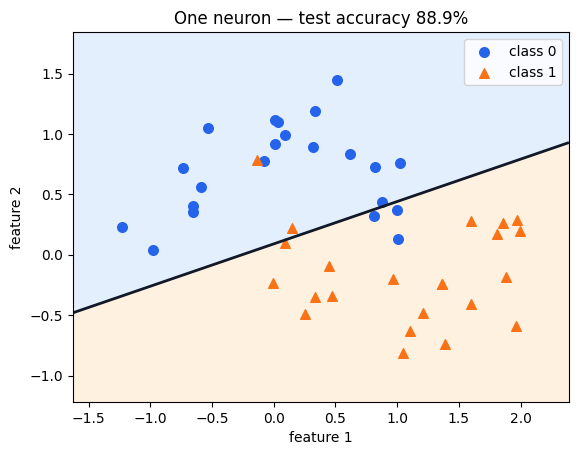

In [13]:
plot_boundary(
    logistic_model, X_test, y_test,
    f"One neuron — test accuracy {logistic_accuracy:.1%}",
)

### Interpret the picture

The model learned the best straight boundary it could. Point to mistakes
that no movement of one straight line can remove.

## 6. ReLU and a hidden layer

ReLU returns zero for negative scores and keeps positive scores. This small
bend prevents stacked layers from collapsing into one linear calculation.

In [14]:
def relu(scores):
    return np.maximum(0, scores)

def dense_layer(inputs, weights, biases):
    return inputs @ weights + biases

In [15]:
relu_inputs = np.array([-2.0, 0.0, 3.0])
print("before ReLU:", relu_inputs)
print("after ReLU: ", relu(relu_inputs))
assert np.all(relu(relu_inputs) >= 0)

before ReLU: [-2.  0.  3.]
after ReLU:  [0. 0. 3.]


### Shape prediction

If `inputs` has shape `(5, 2)` and the hidden layer has three neurons,
what shapes must `W1`, `b1`, and the hidden output have?

In [16]:
rng = np.random.default_rng(4)
W1 = rng.normal(0, 0.5, size=(2, 3))
b1 = np.zeros(3)
W2 = rng.normal(0, 0.5, size=(3, 1))
b2 = np.zeros(1)

print("W1:", W1.shape, "b1:", b1.shape)
print("W2:", W2.shape, "b2:", b2.shape)

W1: (2, 3) b1: (3,)
W2: (3, 1) b2: (1,)


## 7. A small MLP forward pass

We keep the intermediate values because the backward pass needs them.

In [17]:
def mlp_forward(inputs, W1, b1, W2, b2):
    hidden_scores = dense_layer(inputs, W1, b1)
    hidden_outputs = relu(hidden_scores)
    output_scores = dense_layer(hidden_outputs, W2, b2)
    probabilities = sigmoid(output_scores)

    cache = (hidden_scores, hidden_outputs, probabilities)
    return probabilities, cache

In [18]:
batch = X_train[:5]
probabilities, cache = mlp_forward(batch, W1, b1, W2, b2)
hidden_scores, hidden_outputs, _ = cache

print("inputs:            ", batch.shape)
print("hidden scores:     ", hidden_scores.shape)
print("hidden activations:", hidden_outputs.shape)
print("probabilities:     ", probabilities.shape)
print("first probability: ", probabilities[0, 0])

inputs:             (5, 2)
hidden scores:      (5, 3)
hidden activations: (5, 3)
probabilities:      (5, 1)
first probability:  0.47539348387568153


## 8. Classification loss

Binary cross-entropy gives small loss to correct, confident predictions and
large loss to confident mistakes. We use it without deriving logarithms.

In [19]:
def binary_cross_entropy(targets, probabilities):
    probabilities = np.clip(probabilities.ravel(), 1e-8, 1 - 1e-8)

    return -np.mean(
        targets * np.log(probabilities)
        + (1 - targets) * np.log(1 - probabilities)
    )

In [30]:
# a 0.6 -> 1 (0)
# b 0.9 -> 1

# log p

In [20]:
all_probabilities, cache = mlp_forward(X_train, W1, b1, W2, b2)
loss_before = binary_cross_entropy(y_train, all_probabilities)
print("loss before the update:", loss_before)

loss before the update: 0.8225852625421758


## 9. One transparent backward pass

Read this from top to bottom:

1. output error;
2. output-layer gradients;
3. hidden error through the ReLU mask;
4. hidden-layer gradients.

You should understand the direction and shapes—not memorize the formulas.

In [21]:
def mlp_gradients(inputs, targets, W2, cache):
    hidden_scores, hidden_outputs, probabilities = cache
    targets = targets.reshape(-1, 1)

    output_error = (probabilities - targets) / len(inputs)
    gradient_W2 = hidden_outputs.T @ output_error
    gradient_b2 = np.sum(output_error, axis=0)

    hidden_error = output_error @ W2.T
    hidden_score_error = hidden_error * (hidden_scores > 0)
    gradient_W1 = inputs.T @ hidden_score_error
    gradient_b1 = np.sum(hidden_score_error, axis=0)

    return gradient_W1, gradient_b1, gradient_W2, gradient_b2

In [22]:
gradients = mlp_gradients(X_train, y_train, W2, cache)
gradient_W1, gradient_b1, gradient_W2, gradient_b2 = gradients

print("W1 and gradient_W1:", W1.shape, gradient_W1.shape)
print("b1 and gradient_b1:", b1.shape, gradient_b1.shape)
print("W2 and gradient_W2:", W2.shape, gradient_W2.shape)
print("b2 and gradient_b2:", b2.shape, gradient_b2.shape)

W1 and gradient_W1: (2, 3) (2, 3)
b1 and gradient_b1: (3,) (3,)
W2 and gradient_W2: (3, 1) (3, 1)
b2 and gradient_b2: (1,) (1,)


### One update

Every parameter subtracts its matching gradient. Predict whether the loss
should rise or fall before running the next cell.

In [23]:
learning_rate = 0.5
W1 = W1 - learning_rate * gradient_W1
b1 = b1 - learning_rate * gradient_b1
W2 = W2 - learning_rate * gradient_W2
b2 = b2 - learning_rate * gradient_b2

probabilities_after, _ = mlp_forward(X_train, W1, b1, W2, b2)
loss_after = binary_cross_entropy(y_train, probabilities_after)

print("before:", loss_before)
print("after: ", loss_after)
assert loss_after < loss_before

before: 0.8225852625421758
after:  0.7550538772410325


## 10. Let scikit-learn perform full training

The library now repeats forward pass → loss → backward pass → update for us.
We keep one hidden layer with eight neurons.

In [24]:
mlp_model = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(8,), activation="relu", solver="lbfgs",
        alpha=0.01, max_iter=3000, random_state=7,
    ),
)

mlp_model.fit(X_train, y_train)
mlp_predictions = mlp_model.predict(X_test)
mlp_accuracy = accuracy_score(y_test, mlp_predictions)
print("MLP test accuracy:", mlp_accuracy)

MLP test accuracy: 0.9777777777777777


one neuron: 88.9%
small MLP:  97.8%


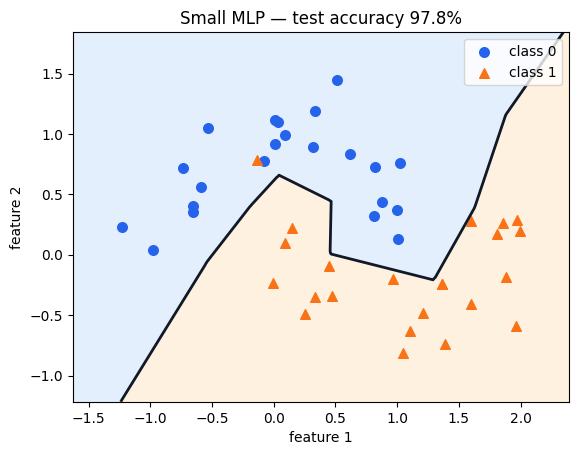

In [25]:
print(f"one neuron: {logistic_accuracy:.1%}")
print(f"small MLP:  {mlp_accuracy:.1%}")

plot_boundary(
    mlp_model, X_test, y_test,
    f"Small MLP — test accuracy {mlp_accuracy:.1%}",
)

### What did the library hide?

`fit` hid the repeated forward passes, losses, backpropagation steps, and
parameter updates. `predict` performs only the forward calculation with the
learned parameters.

## 11. Optional connection back to regression

An MLP can also predict continuous values. The hidden layer lets the prediction
curve bend; the learning loop remains the same.

In [26]:
regression_inputs = np.linspace(-2, 2, 90).reshape(-1, 1)
regression_targets = np.sin(2 * regression_inputs[:, 0]) + 0.25 * regression_inputs[:, 0]

line_model = LinearRegression().fit(regression_inputs, regression_targets)
curve_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(20,), solver="lbfgs",
                 max_iter=3000, random_state=7),
).fit(regression_inputs, regression_targets)

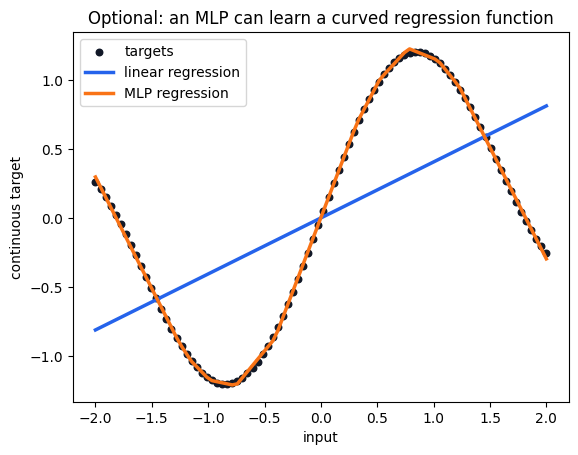

In [27]:
plt.scatter(regression_inputs[:, 0], regression_targets,
            color=INK, s=22, label="targets")
plt.plot(regression_inputs[:, 0], line_model.predict(regression_inputs),
         color=BLUE, linewidth=2.5, label="linear regression")
plt.plot(regression_inputs[:, 0], curve_model.predict(regression_inputs),
         color=ORANGE, linewidth=2.5, label="MLP regression")
plt.xlabel("input")
plt.ylabel("continuous target")
plt.title("Optional: an MLP can learn a curved regression function")
plt.legend()
plt.show()

## Final checks

Explain each statement without reading the code:

1. A linear model is already one neuron.
2. Sigmoid and ReLU have different jobs.
3. A forward pass moves from inputs to prediction.
4. Backpropagation calculates gradients from output toward input.
5. Every gradient must match the shape of its parameter.
6. `fit` learns parameters; `predict` uses them.

**Next:** deeper networks repeat these ideas. We will study representations,
validation, and learning behavior before moving to attention.